<a href="https://colab.research.google.com/github/IdaCy/ParaphrX/blob/main/notebooks/maths_paraphrase_line.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maths Paraphrases Pipeline

This notebook allows to analyse correctness & attention & activations in maths prompts. In order to run these experiments, you need a list of prompts that have a question portion, a colon, and a maths portion:
<question>: <maths>
e.g.
Please solve: 4 + 93.

Your prompts are the `'normal'` prompts. You can give the list to e.g. to [Grok](https://grok.com/) and ask it to generate paraphrases and build a JSON like the below`

Prepare a JSON like this:

```
[
    {
        "element_index": 1,
        "normal": "Solve this task: 4 + 93 =",
        "nicer": "Please solve this task: 4 + 93 =",
        "urgent": "Solve this task urgently: 4 + 93 =",
        ... (possibly more keys)
    },
    {
        "element_index": 2,
        "normal": "Please find the result: 6 - 4 =",
        "nicer": "Please kindly find the result: 6 - 4 =",
        "urgent": "Please find the result immediately: 6 - 4 =",
        ... (possibly more keys)
    },
    {
        "element_index": 3,
        "normal": "What is the solution for: 9 - 7 =",
        "nicer": "Please what is the solution for: 9 - 7 =",
        "urgent": "What is the solution for, extremely important: 9 - 7 =",
        ... (possibly more keys)
    },
... (more curly brackets)
]
```
Fill it with 100 entries.

Then start by importing the required libraries:

In [1]:
# Check Python version (optional):
import sys
print("Python version:", sys.version)

# Get installations
!pip install --quiet torch numpy matplotlib scikit-learn pandas
!pip install --quiet huggingface_hub transformers

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# If you want to check GPU usage:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Python version: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.2 MB/s eta 0:00:00
Using device: cuda


In order to save the results more permanently than just in this session, we use Google Drive. Run the following to connect your drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# After running this cell, follow the link to grant Colab access to your Google Drive.

Mounted at /content/drive


Now, connect the github repository by running the below script.

This repository has one folder for each experiment. It is structured like this:

```
ParaphrX/
├── 0_data/
│   ├── maths.json         <- put your JSON here
│   └── instructions.json
├── 1_utils/
│   ├── hpc/
│   └── run_scripts/       <- always useful scripts
│       ├── load_json.py
│       ├── load_model.py
│       ├── logger.py
│       └── read_predictions.py
├── 2_inference/
│   ├── hpc/
│   └── run_scripts/
│       └── attn_act_logi.py
├── 3_maths_eval/         <- evaluating predictions with mats
│   ├── hpc/
│   └── run_scripts/
│       ├── parse_predictions.py
│       └── evaluate_predictions.py
├── 4_semantics_eval/
│   ├── hpc/
│   └── run_scripts/
├── 5_attention_fractions/
│   ├── hpc/
│   └── run_scripts/
│       └── dirs_eval.py
├── requirements.txt
└── README.md
```

Ignore the `'hpc'`folders for now; it is for running the scripts through the Imperial SLURM.

In [3]:
!git clone https://github.com/IdaCy/ParaphrX.git
%cd ParaphrX

Cloning into 'ParaphrX'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 164 (delta 52), reused 132 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (164/164), 253.29 KiB | 3.17 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/ParaphrX


Now, connect a huggingface account.

If you don't have one yet, set it up - it's really straightforward - and then just click at your profile image, and select in the dropdown to create a `token`. You'll be prompted to insert that token when running the below cell.

In [4]:
!pip install huggingface_hub --quiet
from huggingface_hub import login

# Login to huggingface through token
# If you don't have a token secret yet: uncomment this and put your token in
# !echo "<token>" >> /content/drive/MyDrive/.secrets/hf_token.txt

with open('/content/drive/MyDrive/.secrets/hf_token.txt') as f:
    hf_token = f.read().strip()

# Login with the token
login(token=hf_token)

# Logging Setup

By running the below script, you set up a logger to run during inference. If you don't change the logging level, it will print all the progress stuff to the log file - `progress.log` in the logs/ directory - and only warnings would be printed below the cell.

In [5]:
import logging
from b_utils.run_scripts.logger import init_logger
logging.basicConfig(level=logging.INFO)

logger = init_logger(
    log_file="logs/progress.log",
    console_level=logging.WARNING,  # only warnings to console
    file_level=logging.DEBUG        # full debug info in the file
)

## Inference with Extractions

---
**!Efficiency Information!** You might want to only run this chapter - getting the model & running inference on each prompt type - with a higher-power GPU (e.g. A100). They are saved into your drive. You can then switch to lower GPU or even CPU for any following analysis.
---
---

The below script runs inference with a specific key from your JSON. For example, you may want to start by only running the `normal` prompts through your model.

You have this JSON in your `a_data/`:
```
[
    {
        "element_index": 1,
        "normal": "Solve this task: 4 + 93 =",        <- running this
        "nicer": "Please solve this task: 4 + 93 =",
        ... (possibly more keys)
    },
    {
        "element_index": 2,
        "normal": "Please find the result: 6 - 4 =",  <- running this
        "nicer": "Please kindly find the result: 6 - 4 =",
        ... (possibly more keys)
    },
... (more curly brackets)
]
```

And you would repeatedly run the inference on one 'normal' prompt, capture hidden values, next prompt, capture hidden values...

The results are saved in `c_inference/extractions/`.

Get the functions from the scripts:

In [6]:
from b_utils.run_scripts.load_model import load_model
from b_utils.run_scripts.load_json import load_json_prompts
from c_inference.run_scripts.instruct_tuned_inf import run_inf

With the below script, we download the model weights _once_, they are then stored in 'model' and you won't have to do this relatively higher-compute execution again after. It is used in all your inference runs.

Don't forget exchanging the `None` with your own Huggingface Token (hf_token)!

In [7]:
model, tokenizer = load_model(
    model_name="google/gemma-2-2b-it",
    use_bfloat16=True,
    hf_token=hf_token,
    logger=logger
)

/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:862: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

### Running Inference

You can now run inference on your scripts. It extracts:
- every 5th layer attention
- every 5th layer activations
- final logits
- predictions


In [8]:
# Setup for all inference runs
jfile = "a_data/maths.json"
out_dir = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/"
batch_size = 128

# Make the directory in drive to save results
!mkdir out_dir

In [9]:
# prompt version / JSON key used
prompt = "normal"

data = load_json_prompts(file_path=jfile, prompt_key=prompt, logger=logger)
run_inf(model, tokenizer, data, output_dir=out_dir+prompt, batch_size=batch_size, logger=logger)

[WARNING] === Starting inference. #samples=1000, batch_size=128 ===
`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
[WARNING] === Inference Complete ===


In [10]:
# prompt version / JSON key used
prompt = "nicer"

data = load_json_prompts(file_path=jfile, prompt_key=prompt, logger=logger)
run_inf(model, tokenizer, data, output_dir=out_dir+prompt, batch_size=batch_size, logger=logger)

[WARNING] === Starting inference. #samples=1000, batch_size=128 ===
[WARNING] === Inference Complete ===


In [11]:
# prompt version / JSON key used
prompt = "urgent"

data = load_json_prompts(file_path=jfile, prompt_key=prompt, logger=logger)
run_inf(model, tokenizer, data, output_dir=out_dir+prompt, batch_size=batch_size, logger=logger)

[WARNING] === Starting inference. #samples=1000, batch_size=128 ===
[WARNING] === Inference Complete ===


In [12]:
# any other prompt version / JSON key? - change here
prompt = "insulting"

data = load_json_prompts(file_path=jfile, prompt_key=prompt, logger=logger)
run_inf(model, tokenizer, data, output_dir=out_dir+prompt, batch_size=batch_size, logger=logger)

[WARNING] === Starting inference. #samples=1000, batch_size=128 ===
[WARNING] === Inference Complete ===


## Check Your Predictions

You don't need GPU for this. You can switch to CPU.



In [13]:
from b_utils.run_scripts.read_predictions import read_predictions

In [14]:
import logging
from b_utils.run_scripts.logger import init_logger
logging.basicConfig(level=logging.INFO)

# prompt version you want to read predictions of:
prompt = "normal"

predictions = read_predictions(
    read_output_dir="/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/" + prompt,
    max_predictions=20,
    write_predictions_file="logs/predictions.txt",
    log_file="logs/read_predictions.log"
)
print(f"Collected {len(predictions)} predictions.")

[INFO] === Starting read_predictions function ===
INFO:ReadPredictionsLogger:=== Starting read_predictions function ===
[INFO] read_output_dir = /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal
INFO:ReadPredictionsLogger:read_output_dir = /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal
[INFO] log_file = logs/read_predictions.log
INFO:ReadPredictionsLogger:log_file = logs/read_predictions.log
[INFO] max_predictions = 20
INFO:ReadPredictionsLogger:max_predictions = 20
[INFO] write_predictions_file = logs/predictions.txt
INFO:ReadPredictionsLogger:write_predictions_file = logs/predictions.txt
[INFO] Found 8 .pt files to process.
INFO:ReadPredictionsLogger:Found 8 .pt files to process.
Reading .pt files:   0%|          | 0/8 [00:00<?, ?it/s]DEBUG:ReadPredictionsLogger:Loading file: /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal/activations_00000_00128.pt
[INFO] Reached max_predictions limit; stopping.
INFO:ReadPredictionsLogger

Collected 20 predictions.


## Evaluate Your Predictions

How many tasks did the LLM solve correctly?

Run the below on each prompt type, and find the percentage.

In [15]:
from d_maths_eval.run_scripts.parse_predictions import parse_prediction_text
from d_maths_eval.run_scripts.evaluate_predictions import evaluate_predictions
allowed_operations = "+-*÷"
pt_path = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/"
log_path = "logs/extraction_log_"
results_path = "/content/drive/MyDrive/ParaphrX/d_maths_eval/output"
!mkdir -p results_path

In [16]:
pr_type = "normal"
overall_accuracy = evaluate_predictions(pt_file=pt_path + pr_type,
                                        log_file=log_path + pr_type + ".txt",
                                        allowed_operations=allowed_operations,
                                        results_file=results_path + pr_type + ".txt")

print(f"Overall Correctness: {overall_accuracy:.2f}%")

Overall Correctness: 89.80%


In [17]:
pr_type = "nicer"
overall_accuracy = evaluate_predictions(pt_file=pt_path + pr_type,
                                        log_file=log_path + pr_type + ".txt",
                                        allowed_operations=allowed_operations,
                                        results_file=results_path + pr_type + ".txt")

print(f"Overall Correctness: {overall_accuracy:.2f}%")

Overall Correctness: 89.30%


In [18]:
pr_type = "urgent"
overall_accuracy = evaluate_predictions(pt_file=pt_path + pr_type,
                                        log_file=log_path + pr_type + ".txt",
                                        allowed_operations=allowed_operations,
                                        results_file=results_path + pr_type + ".txt")

print(f"Overall Correctness: {overall_accuracy:.2f}%")

Overall Correctness: 90.30%


In [19]:
pr_type = "insulting"
overall_accuracy = evaluate_predictions(pt_file=pt_path + pr_type,
                                        log_file=log_path + pr_type + ".txt",
                                        allowed_operations=allowed_operations,
                                        results_file=results_path + pr_type + ".txt")

print(f"Overall Correctness: {overall_accuracy:.2f}%")

Overall Correctness: 91.10%


## Attention Analysis

This part analyses how much attention was on the different parts of the prompts.

All the result files (PT files) are stored in dedicated directories - which are all part of one overall directory. You pass along the path to the overall directory, and it will compare all your prompt outputs.

Found 8 .pt files in: /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal (prompt_type='normal')
Found 8 .pt files in: /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/nicer (prompt_type='nicer')
Found 8 .pt files in: /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/urgent (prompt_type='urgent')
Found 8 .pt files in: /content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/insulting (prompt_type='insulting')
=== Average fraction of attention on prompt vs. task portion ===
             frac_prompt  frac_task
prompt_type                        
insulting       0.823056   0.176944
nicer           0.819701   0.180299
normal          0.807934   0.192066
urgent          0.831313   0.168687
Saved fraction summary CSV to: /content/drive/MyDrive/ParaphrX/f_attention_fractions/output/normal_nicer_urgent_insulting/prompt_task_fraction_aggregate.csv


<Figure size 640x480 with 0 Axes>

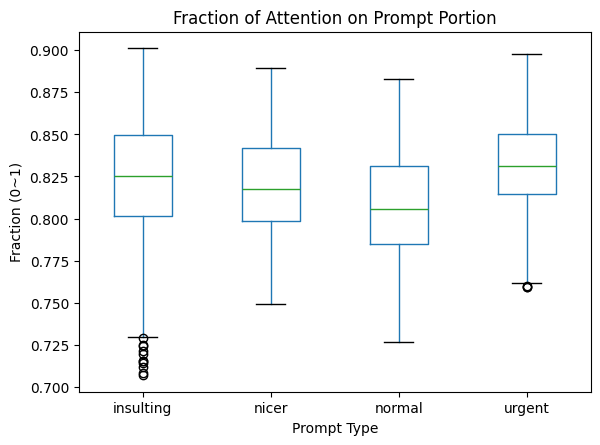

<Figure size 640x480 with 0 Axes>

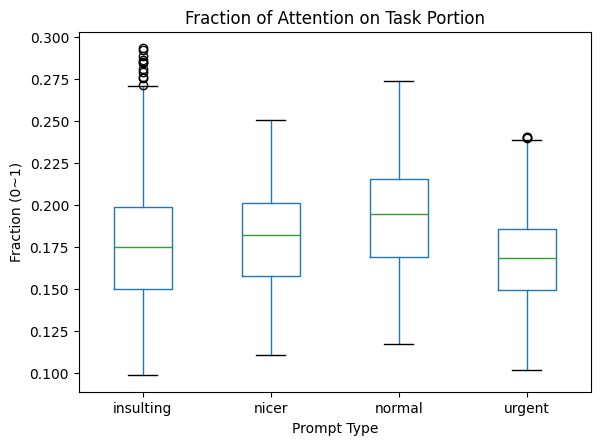

=== Per-layer average fraction of attention on prompt vs. task ===
                   frac_prompt  frac_task
prompt_type layer                        
insulting   0         0.605404   0.394596
            5         0.605401   0.394599
            10        0.605401   0.394599
            15        0.605403   0.394597
nicer       0         0.592446   0.407554
            5         0.592445   0.407555
            10        0.592444   0.407556
            15        0.592447   0.407553
normal      0         0.571770   0.428230
            5         0.571766   0.428234
            10        0.571766   0.428234
            15        0.571769   0.428231
urgent      0         0.627444   0.372556
            5         0.627441   0.372559
            10        0.627442   0.372558
            15        0.627444   0.372556
Saved per-layer fraction CSV to: /content/drive/MyDrive/ParaphrX/f_attention_fractions/output/normal_nicer_urgent_insulting/prompt_task_fraction_perlayer.csv


<Figure size 640x480 with 0 Axes>

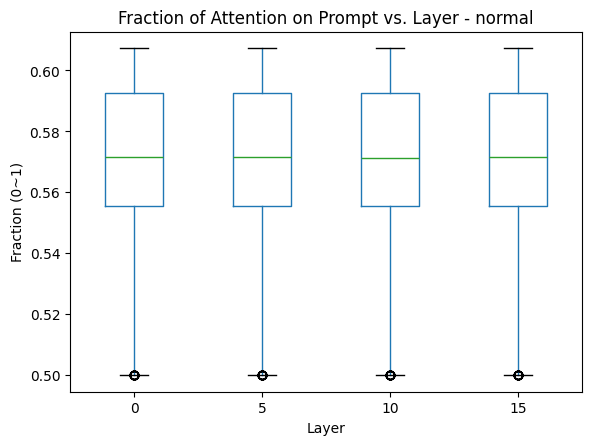

<Figure size 640x480 with 0 Axes>

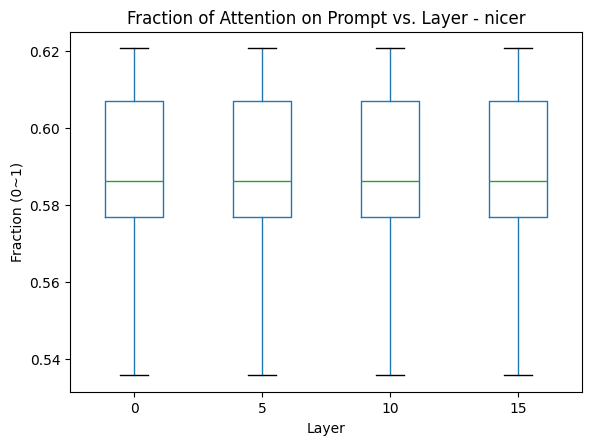

<Figure size 640x480 with 0 Axes>

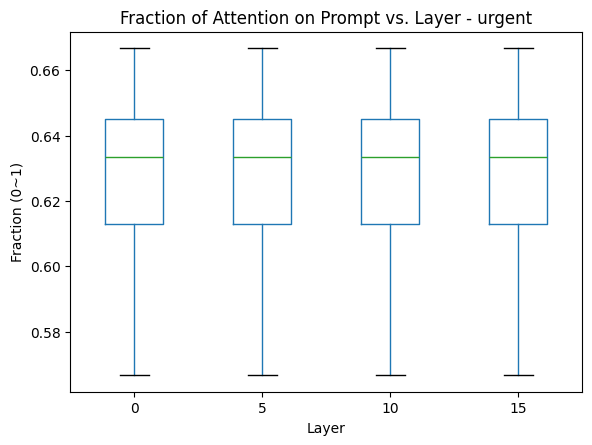

<Figure size 640x480 with 0 Axes>

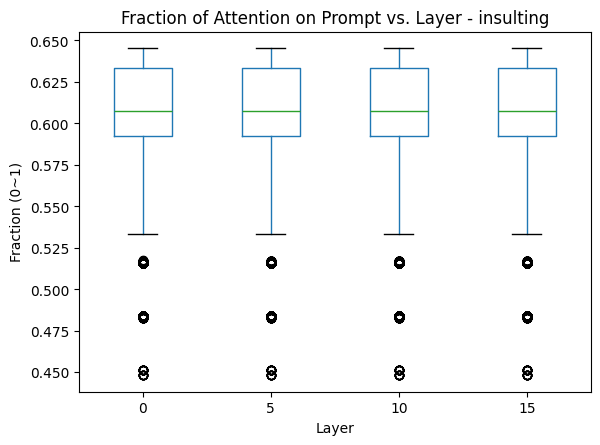

All plots and CSVs saved to: /content/drive/MyDrive/ParaphrX/f_attention_fractions/output/normal_nicer_urgent_insulting
Done!


In [21]:
from f_attention_fractions.run_scripts.dirs_eval import run_attention_extraction
!mkdir -p "/content/drive/MyDrive/ParaphrX/f_attention_fractions/output"

run_attention_extraction(
    tokenizer=tokenizer,
    extraction_base_dir="/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/",
    prompt_types="normal nicer urgent insulting",
    output_dir="/content/drive/MyDrive/ParaphrX/f_attention_fractions/output"
)

In [22]:
!git pull

Already up to date.


In [23]:
from g_linear_class.run_scripts.train_classifier2 import load_features_from_dir, train_and_evaluate

In [24]:
dir1 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal"
dir2 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/nicer"

In [25]:
layer = 0

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 0: Mean cross-validation accuracy = 91.00%


In [26]:
layer = 5

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 5: Mean cross-validation accuracy = 92.35%


In [27]:
layer = 10

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 10: Mean cross-validation accuracy = 92.25%


In [28]:
layer = 15

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Layer 15: Mean cross-validation accuracy = 92.05%


In [29]:
dir1 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal"
dir2 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/urgent"

In [30]:
layer = 0

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 0: Mean cross-validation accuracy = 100.00%


In [31]:
layer = 5

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 5: Mean cross-validation accuracy = 100.00%


In [32]:
dir1 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/normal"
dir2 = "/content/drive/MyDrive/ParaphrX/c_inference/extractions_g2bit/insulting"

In [33]:
layer = 10

# Load features from each condition
features1 = load_features_from_dir(dir1, layer)
features2 = load_features_from_dir(dir2, layer)

# Create labels: 0 for normal and 1 for nicer
labels1 = np.zeros(features1.shape[0], dtype=int)
labels2 = np.ones(features2.shape[0], dtype=int)

X = np.concatenate([features1, features2], axis=0)
y = np.concatenate([labels1, labels2], axis=0)

mean_acc = train_and_evaluate(X, y, cv=5)
print(f"Layer {layer}: Mean cross-validation accuracy = {mean_acc*100:.2f}%")

Layer 10: Mean cross-validation accuracy = 99.90%
